In [1]:
import pandas as pd
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lifelines import CoxPHFitter
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_recall_curve, auc, average_precision_score, precision_score, recall_score, f1_score
from sklearn.calibration import calibration_curve
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

## Data Loading and Preprocessing

In [2]:
# load cleaned data
df_clean = pd.read_csv("data/Telco_churn_cleaned.csv")

# data prep
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

# balance technique: Random Under-Sampling 
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)

# train-test split (80:20)
X = X_rus
y = y_rus
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/Users/andy/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/andy/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


## Naive Model

In [3]:
naive_model = DummyClassifier(strategy="most_frequent")
naive_model.fit(X_train, y_train)

y_pred_naive = naive_model.predict(X_test)
print(classification_report(y_test, y_pred_naive, zero_division=0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       379
           1       0.49      1.00      0.66       369

    accuracy                           0.49       748
   macro avg       0.25      0.50      0.33       748
weighted avg       0.24      0.49      0.33       748



## Linear Regression

In [4]:
# scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression Report:")
print(classification_report(y_test, lr_model.predict(X_test_scaled)))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80       379
           1       0.79      0.81      0.80       369

    accuracy                           0.80       748
   macro avg       0.80      0.80      0.80       748
weighted avg       0.80      0.80      0.80       748



## Random Forest

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Report:")
print(classification_report(y_test, rf_model.predict(X_test)))

Random Forest Report:
              precision    recall  f1-score   support

           0       0.79      0.78      0.78       379
           1       0.77      0.78      0.78       369

    accuracy                           0.78       748
   macro avg       0.78      0.78      0.78       748
weighted avg       0.78      0.78      0.78       748



In [7]:
# Create a DataFrame of feature importances sorted highest to lowest
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances.head())

              Feature  Importance
4       Tenure Months    0.088460
8       Total Charges    0.084487
15   Cost_Per_Service    0.075672
9   Avg Monthly Spend    0.073079
7     Monthly Charges    0.072337


## XGBoost

In [8]:
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

print("XGBoost Report:")
print(classification_report(y_test, xgb_model.predict(X_test)))

XGBoost Report:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76       379
           1       0.75      0.79      0.77       369

    accuracy                           0.76       748
   macro avg       0.76      0.76      0.76       748
weighted avg       0.76      0.76      0.76       748



## Cox Proportional Hazards

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'Tenure Months'
                event col = 'Churn'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13378.11
         time fit was run = 2026-04-16 03:16:15 UTC

---
                                          coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                                 
Gender                                   -0.04      0.96      0.04           -0.12            0.04                0.89                1.04
Senior Citizen                            0.01      1.01      0.05           -0.08            0.11                0.92                1.12
Partner                                  -0.18      0.83      0.04           -0.27           -0.10                0.77                0.90
Dependents                               -0.58      0.56      0.06           -0.70           -0.46                0.50                0.63
Phone Service                            -0.02      0.98      0.10           -0.22            0.18                0.80                1.20
Paperless Billing                         0.14      1.15      0.05            0.05            0.23                1.05                1.26
Monthly Charges                           0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Total Charges                            -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
Avg Monthly Spend                         0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Tenure Group                             -0.44      0.64      0.02           -0.47           -0.41                0.62                0.67
Bill_Shock_Ratio                          0.09      1.10      0.41           -0.72            0.90                0.49                2.46
Total_Addon_Services                     -0.01      0.99      0.02           -0.05            0.02                0.95                1.02
High_Risk_Security_Profile                0.18      1.20      0.06            0.06            0.30                1.06                1.35
Is_Auto_Pay                              -0.19      0.83      0.06           -0.31           -0.07                0.73                0.93
Cost_Per_Service                          0.00      1.00      0.00            0.00            0.01                1.00                1.01
Multiple Lines_No                         0.08      1.08      0.06           -0.03            0.19                0.97                1.21
Multiple Lines_No phone service           0.02      1.02      0.10           -0.18            0.22                0.83                1.25
Multiple Lines_Yes                       -0.09      0.92      0.06           -0.20            0.03                0.82                1.03
Internet Service_DSL                     -0.16      0.85      0.06           -0.29           -0.04                0.75                0.96
Internet Service_Fiber optic              0.21      1.24      0.06            0.09            0.34                1.09                1.40
Internet Service_No                      -0.09      0.91      0.09           -0.26            0.08                0.77                1.08
Online Security_No                        0.17      1.18      0.06            0.05            0.29                1.05                1.34
Online Security_No internet service      -0.09      0.91      0.09           -0.26            0.08                0.77                1.08
Online Security_Yes                      -0.13      0.88      0.07           -0.26       

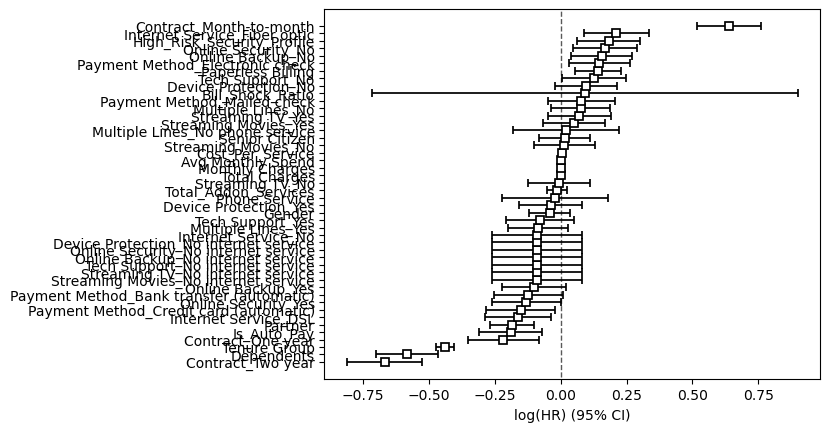

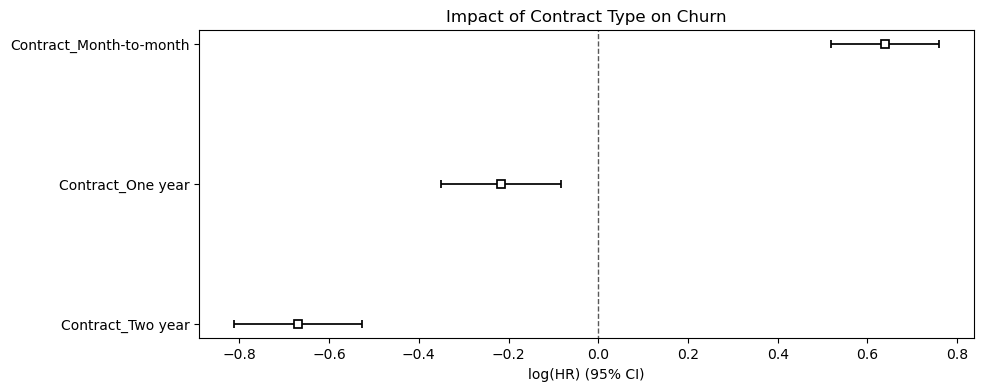

In [9]:
# 1. Handle Categorical Data (Essential for Cox)
# Using drop_first=True prevents the "singular matrix" error from redundant columns
df_cox = pd.get_dummies(df_clean, drop_first=True)

# 2. Initialize with a penalizer
# This "smoothes" the math and handles high correlation between features
cph = CoxPHFitter(penalizer=0.1) 

# 3. Fit using your specific column names
cph.fit(df_cox, duration_col='Tenure Months', event_col='Churn')

# 4. Display results
cph.print_summary()

# 5. Visualize the Hazard Ratios
# This shows which features push customers toward churn (right of 0) or away (left of 0)
cph.plot()

# Example: Plotting only Contract-related features
contract_cols = [col for col in df_cox.columns if 'Contract' in col]

plt.figure(figsize=(10, 4))
cph.plot(columns=contract_cols)
plt.title("Impact of Contract Type on Churn")
plt.show()

## Model Evaluation

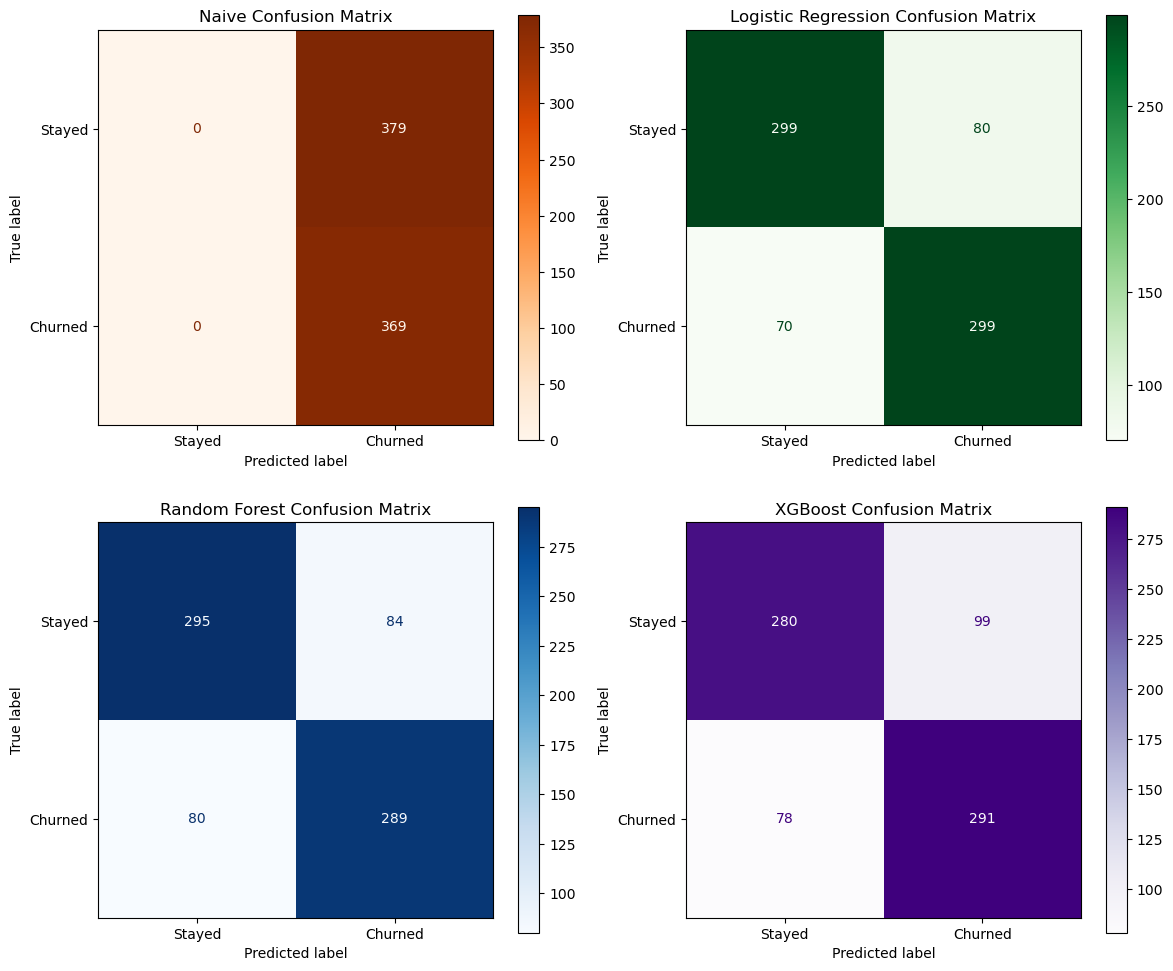

In [10]:
# dictionary linking your names to trained models
models_to_plot = {
    "Naive": naive_model,
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

# color mapping
color_map_dict = {
    "Naive": plt.cm.Oranges,
    "Logistic Regression": plt.cm.Greens,
    "Random Forest": plt.cm.Blues,
    "XGBoost": plt.cm.Purples
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Modified Loop to handle scaled vs unscaled data
for i, (name, model) in enumerate(models_to_plot.items()):
    
    if name == "Logistic Regression":
        y_pred = model.predict(X_test_scaled) # Use scaled data for LR
    else:
        y_pred = model.predict(X_test)        # Use unscaled data for the trees and naive model
        
    cm = confusion_matrix(y_test, y_pred)
    
    current_cmap = color_map_dict.get(name, plt.cm.Reds) 
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=axes[i], cmap=current_cmap)
    axes[i].set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

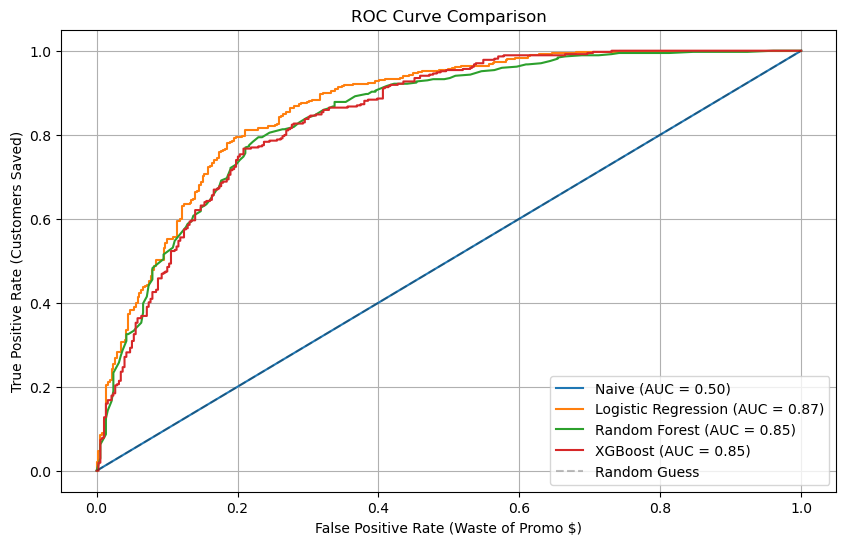

In [11]:
# Get predicted probabilities 
models = {
    'Naive': naive_model,
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

plt.figure(figsize=(10, 6))

for name, model in models.items():
    # 1. Route the correct test data
    if name == 'Logistic Regression':
        X_data = X_test_scaled
    else:
        X_data = X_test
        
    # 2. Predict probabilities using the correct data
    probs = model.predict_proba(X_data)[:, 1]
    
    # 3. Calculate metrics and plot
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

# Plot the random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', alpha=0.25)
plt.xlabel('False Positive Rate (Waste of Promo $)')
plt.ylabel('True Positive Rate (Customers Saved)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()
plt.show()

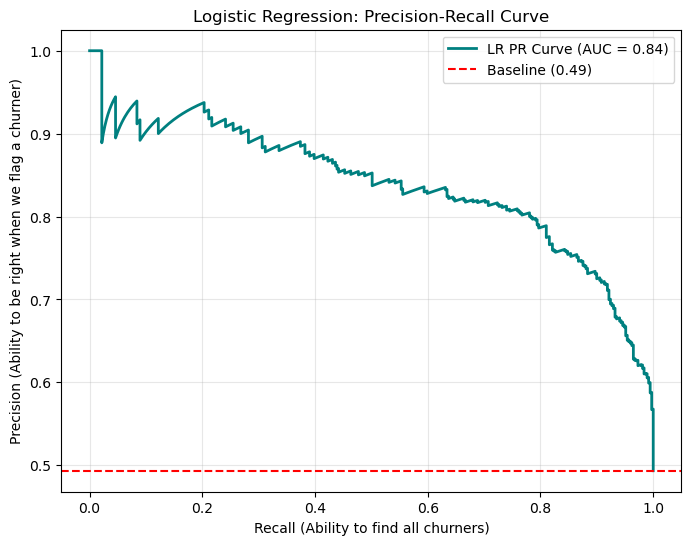

In [12]:
from sklearn.metrics import auc

# Get the probability scores for the positive class (churners)
y_scores = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate precision and recall for various thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Calculate the Area Under the PR Curve (AUC-PR)
pr_auc = auc(recall, precision)

# Plotting the Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'LR PR Curve (AUC = {pr_auc:.2f})', color='teal', lw=2)

# Baseline of churners in the dataset
# (Since we used RandomUnderSampler, this baseline should be exactly 0.50!)
baseline = sum(y_test) / len(y_test)
plt.axhline(y=baseline, color='red', linestyle='--', label=f'Baseline ({baseline:.2f})')

plt.xlabel('Recall (Ability to find all churners)')
plt.ylabel('Precision (Ability to be right when we flag a churner)')
plt.title('Logistic Regression: Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

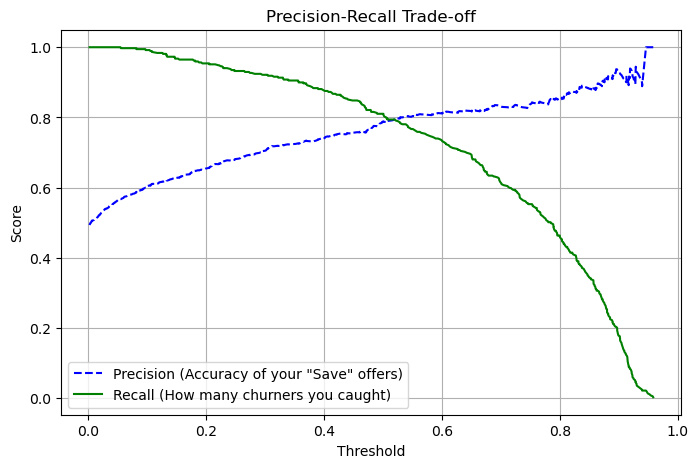

In [13]:
#get probabilities for churn
y_scores = lr_model.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], 'b--', label='Precision (Accuracy of your "Save" offers)')
plt.plot(thresholds, recall[:-1], 'g-', label='Recall (How many churners you caught)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Example Costs (Adjust these based on your business)
cost_of_churn = 100 
cost_of_retention_offer = 20

profits = []
threshold_range = np.linspace(0, 1, 100)

for t in threshold_range:
    preds = (y_scores >= t).astype(int)
    # True Positives: People we saved (Benefit = Churn Cost - Offer Cost)
    tp = np.sum((preds == 1) & (y_test == 1))
    # False Positives: People we gave a useless discount (Cost = Offer Cost)
    fp = np.sum((preds == 1) & (y_test == 0))
    
    total_profit = (tp * (cost_of_churn - cost_of_retention_offer)) - (fp * cost_of_retention_offer)
    profits.append(total_profit)

best_threshold = threshold_range[np.argmax(profits)]
print(f"The mathematically optimal threshold is: {best_threshold:.2f}")

The mathematically optimal threshold is: 0.13


In [15]:
#get raw probabilities
y_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

#define the thresholds to test
thresholds = [0.15, 0.30, 0.50, 0.70]
results = []

for t in thresholds:
    #apply threshold
    y_pred_t = (y_probs >= t).astype(int)
    
    #calculate metrics
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    #how many people targeted for retention
    total_targeted = y_pred_t.sum()
    
    results.append({
        "Threshold": t,
        "Precision (Quality)": f"{(precision * 100):.1f}%",
        "Recall (Quantity)": f"{(recall * 100):.1f}%",
        "F1-Score": f"{f1:.2f}",
        "Customers Flagged": total_targeted
    })

#clean table
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 Threshold Precision (Quality) Recall (Quantity) F1-Score  Customers Flagged
      0.15               62.9%             96.7%     0.76                568
      0.30               70.5%             92.1%     0.80                482
      0.50               78.9%             81.0%     0.80                379
      0.70               83.1%             61.2%     0.71                272


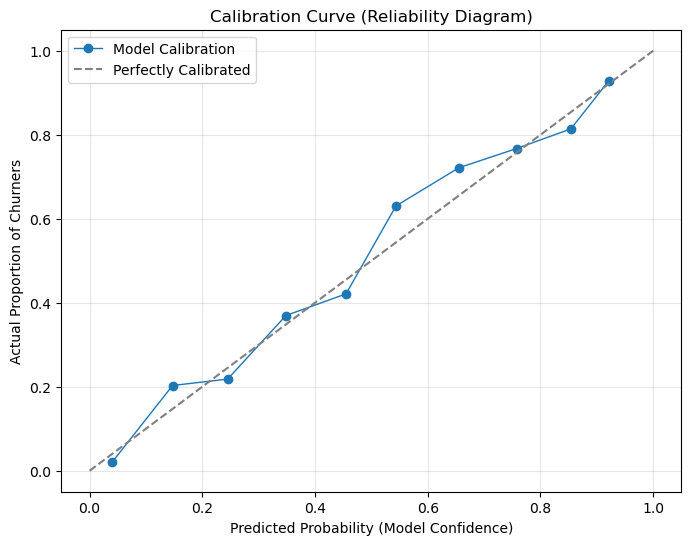

In [16]:
# 1. Calculate calibration binned counts
# y_test: actual outcomes, y_scores: predicted probabilities
prob_true, prob_pred = calibration_curve(y_test, y_scores, n_bins=10)

# 2. Plotting
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='Model Calibration')

# The "Perfect" Line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

plt.xlabel('Predicted Probability (Model Confidence)')
plt.ylabel('Actual Proportion of Churners')
plt.title('Calibration Curve (Reliability Diagram)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Hyperparameter Tuning

In [17]:
# Define the Parameter Grids

# Logistic Regression: Tuning regularization strength (C)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'] # default solver 'lbfgs' only supports l2
}

# Random Forest: Tuning tree count, depth, and split logic
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# XGBoost: Tuning learning rate, tree depth, and tree count
param_grid_xgb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200]
}

In [18]:
# Setup GridSearchCV
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5, n_jobs=-1)

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, n_jobs=-1)

grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss', random_state=42), param_grid_xgb, cv=5, n_jobs=-1)

In [19]:
# Fit the Grids
print("Tuning Logistic Regression...")
grid_lr.fit(X_train_scaled, y_train) # SCALED

print("Tuning Random Forest...")
grid_rf.fit(X_train, y_train)        # UNSCALED

print("Tuning XGBoost...")
grid_xgb.fit(X_train, y_train)       # UNSCALED

Tuning Logistic Regression...
Tuning Random Forest...
Tuning XGBoost...


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200]})

In [20]:
# --- Extract Best Models ---
best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_
best_xgb = grid_xgb.best_estimator_

print(f"Logistic Regression: {grid_lr.best_params_}")
print(f"Random Forest: {grid_rf.best_params_}")
print(f"XGBoost: {grid_xgb.best_params_}")

Logistic Regression: {'C': 100, 'penalty': 'l2'}
Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


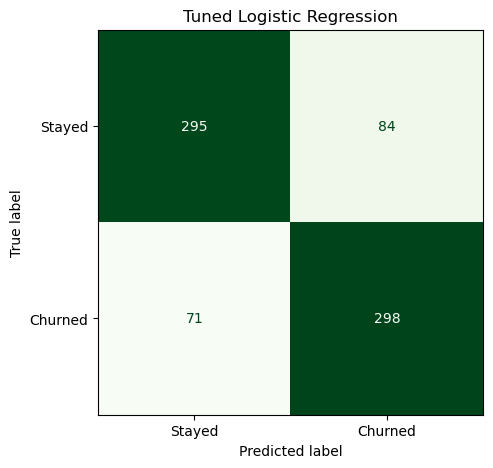

              precision    recall  f1-score   support

           0       0.81      0.78      0.79       379
           1       0.78      0.81      0.79       369

    accuracy                           0.79       748
   macro avg       0.79      0.79      0.79       748
weighted avg       0.79      0.79      0.79       748



In [21]:
# Tuned Logistic Regression
y_pred_lr = best_lr.predict(X_test_scaled)

# Plot Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 5))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Stayed', 'Churned'])
disp_lr.plot(ax=ax, cmap=plt.cm.Greens, colorbar=False)
ax.set_title('Tuned Logistic Regression')
plt.show()

print(classification_report(y_test, y_pred_lr))

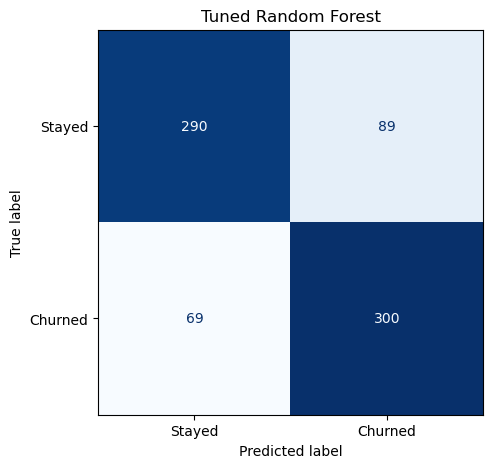

              precision    recall  f1-score   support

           0       0.81      0.77      0.79       379
           1       0.77      0.81      0.79       369

    accuracy                           0.79       748
   macro avg       0.79      0.79      0.79       748
weighted avg       0.79      0.79      0.79       748



In [22]:
# --- Tuned Random Forest ---
y_pred_rf = best_rf.predict(X_test)

# Plot Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 5))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Stayed', 'Churned'])
disp_rf.plot(ax=ax, cmap=plt.cm.Blues, colorbar=False)
ax.set_title('Tuned Random Forest')
plt.show()

print(classification_report(y_test, y_pred_rf))

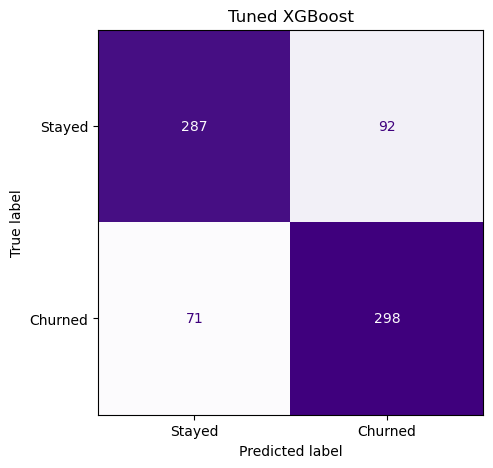

              precision    recall  f1-score   support

           0       0.80      0.76      0.78       379
           1       0.76      0.81      0.79       369

    accuracy                           0.78       748
   macro avg       0.78      0.78      0.78       748
weighted avg       0.78      0.78      0.78       748



In [23]:
# --- Tuned XGBoost ---
y_pred_xgb = best_xgb.predict(X_test)

# Plot Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(5, 5))
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Stayed', 'Churned'])
disp_xgb.plot(ax=ax, cmap=plt.cm.Purples, colorbar=False)
ax.set_title('Tuned XGBoost')
plt.show()

print(classification_report(y_test, y_pred_xgb))

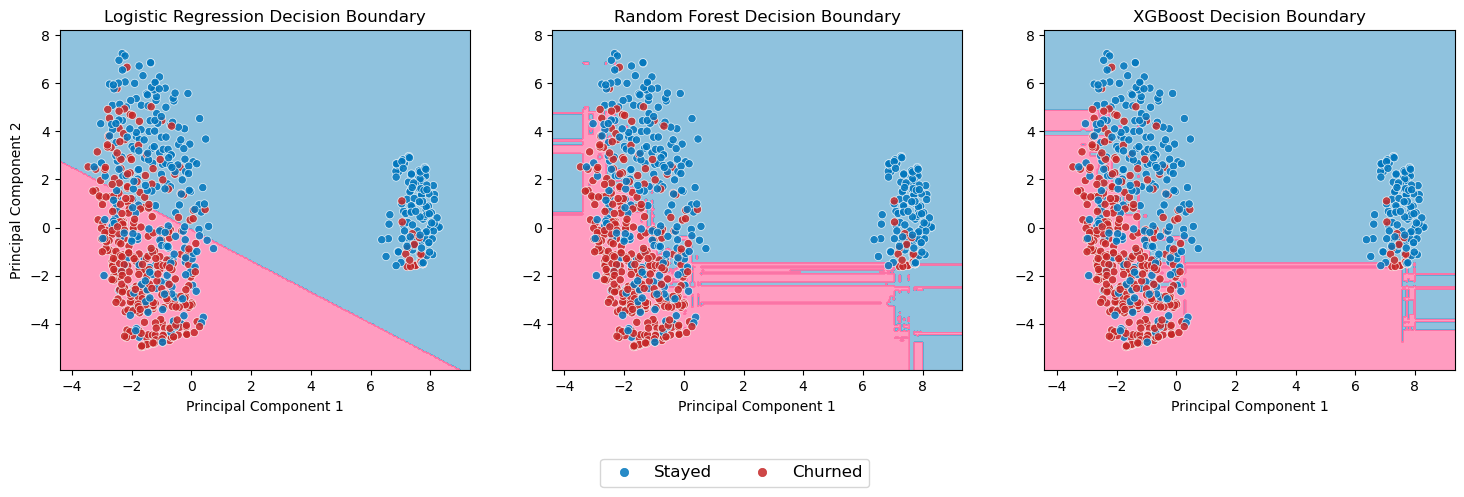

In [24]:
# Reduce Dimensions to 2D using PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Retrain Models on 2D Data
lr_2d = best_lr.__class__(**best_lr.get_params()).fit(X_train_pca, y_train)
rf_2d = best_rf.__class__(**best_rf.get_params()).fit(X_train_pca, y_train)
xgb_2d = best_xgb.__class__(**best_xgb.get_params()).fit(X_train_pca, y_train)

models_2d = {
    "Logistic Regression": lr_2d,
    "Random Forest": rf_2d,
    "XGBoost": xgb_2d
}

# Setup Meshgrid for Plotting
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

cmap_boundary = ListedColormap(['#60a8d1', '#ff73a6']) # Light Blue / Light Pink for background regions
cmap_points = ListedColormap(['#0277bd', '#c62828'])   # Deep Blue / Deep Red for data points

for i, (name, model) in enumerate(models_2d.items()):
    # Predict over the entire grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundary background (Uniform across all plots)
    axes[i].contourf(xx, yy, Z, alpha=0.7, cmap=cmap_boundary)
    
    # Plot the actual testing points on top with clearer colors and borders
    scatter = axes[i].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, 
                              cmap=cmap_points, edgecolors='white', linewidths=0.5, s=35, alpha=0.85)
    
    axes[i].set_title(f'{name} Decision Boundary')
    axes[i].set_xlabel('Principal Component 1')
    
    # Only show the Y-axis label on the far-left plot to keep it clean
    if i == 0:
        axes[i].set_ylabel('Principal Component 2')

# Create a single, shared legend
handles, labels = scatter.legend_elements()
fig.legend(handles, ['Stayed', 'Churned'], loc='lower center', 
           bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize='large', frameon=True)

plt.subplots_adjust(bottom=0.2)
plt.show()